In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#loading dataset
df = pd.read_parquet("../outputs/pheme_prepared_english.parquet")
print("Original shape: ",df.shape)
print("threads:", df["thread_id"].nunique())
print("events:", df["event"].nunique())
df.head()

Original shape:  (94395, 101)
threads: 5802
events: 5


,contributors,truncated,text,in_reply_to_status_id,id,favorite_count,source,retweeted,coordinates,in_reply_to_screen_name,...,metadata_iso_language_code,metadata_result_type,place_attributes_street_address,n_hashtags,n_urls,n_mentions,n_media,n_symbols,source_time,time_since_source_min
0,None,False,Black teenage boys are not men. They are child...,NaN,498235547685756928,124,"<a href=""http://twitter.com/#!/download/ipad"" ...",False,NaN,NaN,...,NaN,NaN,NaN,1,0,0,0,0,2014-08-09 22:33:06+00:00,0.000000
1,None,False,@annaxsweat @NeoSoulPol Same thing when #Trayv...,4.982355e+17,498243332204949504,0,"<a href=""https://about.twitter.com/products/tw...",False,NaN,annaxsweat,...,NaN,NaN,NaN,3,0,2,0,0,2014-08-09 22:33:06+00:00,30.916667
2,None,False,@annaxsweat #StopThugCops We have to take acti...,4.982355e+17,498266827676741632,2,"<a href=""http://twitter.com/#!/download/ipad"" ...",False,NaN,annaxsweat,...,NaN,NaN,NaN,2,0,1,0,0,2014-08-09 22:33:06+00:00,124.283333
3,None,False,@annaxsweat @KidFriendlyCamb 17 year olds can ...,4.982355e+17,498272808560889858,0,"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",False,NaN,annaxsweat,...,NaN,NaN,NaN,0,0,2,0,0,2014-08-09 22:33:06+00:00,148.050000
4,None,False,"@annaxsweat well, he damn sure ain't a child",4.982355e+17,498312902928244736,1,"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",False,NaN,annaxsweat,...,NaN,NaN,NaN,0,0,1,0,0,2014-08-09 22:33:06+00:00,307.366667


### **Thread-Level Characteristics**

### Thread Size Distribution(How many tweets exist in each thread?)


In [3]:
thread_stats = (
    df.groupby("thread_id")
    .agg(
        thread_size=("id", "size"),
        label=("label_name", "first")
    )
)

thread_stats.head()

,thread_size,label
thread_id,,
498235547685756928,12,non-rumours
498248415223246848,25,non-rumours
498248648699150336,50,non-rumours
498250100079341568,5,non-rumours
498251940997136384,8,non-rumours


In [4]:
thread_stats["thread_size"].describe()

count    5802.000000
mean       16.269390
std        19.379577
min         1.000000
25%         6.000000
50%        12.000000
75%        20.000000
max       331.000000
Name: thread_size, dtype: float64

In [5]:
#by label
thread_stats.groupby("label")["thread_size"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non-rumours,3830.0,17.157963,20.924864,1.0,6.0,13.0,20.0,331.0
rumours,1972.0,14.543611,15.819332,1.0,5.0,11.0,19.0,220.0


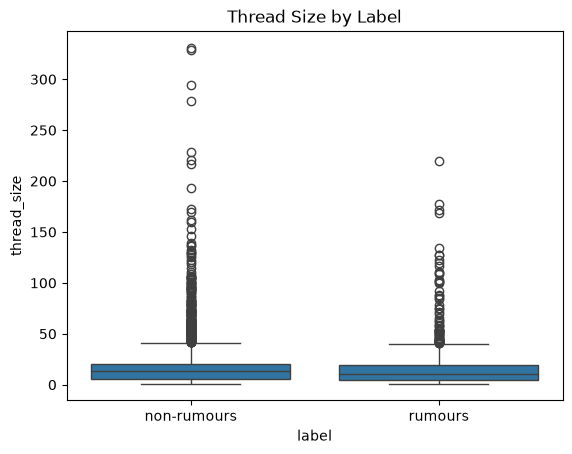

In [6]:
sns.boxplot(
    data=thread_stats,
    x="label",
    y="thread_size"
)

plt.title("Thread Size by Label")
plt.show()

### Source Tweet vs Reply Ratio

In [7]:
source_count = (df["is_source_tweet"] == 1).sum()

reply_count = (df["is_source_tweet"] == 0).sum()

print("Source tweets:", source_count)
print("Replies:", reply_count)

Source tweets: 5802
Replies: 88593


### Unique Authors per Thread

In [8]:
author_stats = (
    df.groupby("thread_id")
    .agg(
        authors=("user_id", "nunique"),
        label=("label_name", "first")
    )
)

author_stats.head()

,authors,label
thread_id,,
498235547685756928,8,non-rumours
498248415223246848,17,non-rumours
498248648699150336,44,non-rumours
498250100079341568,4,non-rumours
498251940997136384,8,non-rumours


In [9]:
author_stats["authors"].describe()

count    5802.000000
mean       10.665460
std         7.247962
min         1.000000
25%         5.000000
50%        10.000000
75%        15.000000
max       125.000000
Name: authors, dtype: float64

In [10]:
author_stats.groupby("label")["authors"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non-rumours,3830.0,10.884334,7.636112,1.0,5.0,10.0,16.0,125.0
rumours,1972.0,10.240365,6.407998,1.0,5.0,10.0,15.0,41.0


### Threads with Zero Replies (A thread with only the source tweet)

In [11]:
thread_size = (
    df.groupby("thread_id")
    .size()
)

zero_reply_threads = (
    thread_size == 1
).sum()

print("Threads with zero replies:", zero_reply_threads)

Threads with zero replies: 401


In [12]:
zero_reply_pct = (
    zero_reply_threads
    / len(thread_size)
    * 100
)

print(f"{zero_reply_pct:.2f}%")

6.91%


### **Temporal Characteristics**


### Thread duration(How long discussions remain active)


In [13]:
thread_time = (
    df.groupby("thread_id")
      .agg(
          start=("created_at", "min"),
          end=("created_at", "max"),
          label=("label_name", "first")
      )
)

thread_time["duration_hours"] = (
    thread_time["end"] - thread_time["start"]
).dt.total_seconds() / 3600

thread_time["duration_hours"].describe()

count    5802.000000
mean       14.844798
std        39.063047
min         0.000000
25%         0.678056
50%         2.674722
75%        11.396319
max       728.756111
Name: duration_hours, dtype: float64

In [14]:
#by label
thread_time.groupby("label")["duration_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non-rumours,3830.0,17.622264,41.776273,0.0,0.844306,3.518750,15.134167,717.431389
rumours,1972.0,9.450429,32.503777,0.0,0.477014,1.672083,5.711389,728.756111


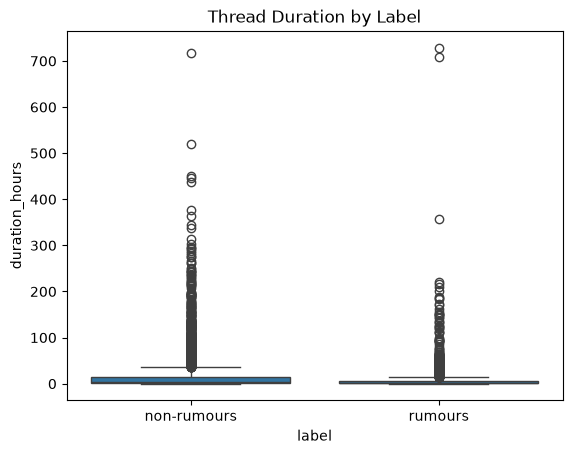

In [15]:
sns.boxplot(
    data=thread_time,
    x="label",
    y="duration_hours"
)

plt.title("Thread Duration by Label")
plt.show()

### Time to first reply

In [16]:
replies = df[df["is_source_tweet"] == 0]
first_reply = (
    replies.groupby("thread_id")
           ["time_since_source_min"]
           .min()
           .reset_index()
)

In [17]:
labels = (
    df.groupby("thread_id")["label_name"]
      .first()
      .reset_index()
)

first_reply = first_reply.merge(
    labels,
    on="thread_id"
)

In [18]:
first_reply.groupby("label_name")[
    "time_since_source_min"
].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
non-rumours,3553.0,27.637869,163.747049,0.050000,1.216667,2.60,6.9000,4331.033333
rumours,1848.0,17.062455,265.700408,0.016667,0.916667,1.75,4.1375,8561.116667


### Median Inter-Reply Gap (How frequently replies arrive?)



In [19]:
df = df.sort_values(
    ["thread_id", "created_at"]
)

df["gap_min"] = (
    df.groupby("thread_id")["created_at"]
      .diff()
      .dt.total_seconds() / 60
)

df["gap_min"].describe()

count    88593.000000
mean        58.331596
std        518.315290
min          0.000000
25%          0.633333
50%          1.833333
75%          7.333333
max      43109.716667
Name: gap_min, dtype: float64

In [20]:
df.groupby("label_name")[
    "gap_min"
].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
non-rumours,61885.0,65.437446,532.366114,0.0,0.666667,1.95,8.233333,26562.733333
rumours,26708.0,41.866661,483.802457,0.0,0.583333,1.60,5.750000,43109.716667


### Early reply volume

Here counting replies appearing within:

* 5min

* 15min

* 30min

* 60min

In [21]:
summary = []

for w in [5, 15, 30, 60]:
    
    counts = (
        df[
            (df["time_since_source_min"] <= w)
            &
            (df["is_source_tweet"] == 0)
        ]
        .groupby("thread_id")
        .size()
    )
    
    summary.append({
        "window_min": w,
        "active_threads": len(counts),
        "pct_threads %": len(counts)/5802*100,
        "median_replies": counts.median(),
        "mean_replies": counts.mean()
    })

pd.DataFrame(summary)

,window_min,active_threads,pct_threads %,median_replies,mean_replies
0,5,3894,67.114788,3.0,3.709296
1,15,4744,81.764909,5.0,6.458685
2,30,5019,86.504654,6.0,8.451684
3,60,5172,89.141675,8.0,10.526295


### Thread half-life

Time required for a thread to accumulate 50% of its final replies.

In [22]:
# Replies only
replies = df[df["is_source_tweet"] == 0].copy()

half_life_data = []

for thread_id, group in replies.groupby("thread_id"):

    group = group.sort_values("time_since_source_min")

    total_replies = len(group)

    if total_replies == 0:
        continue

    half_reply_index = int(np.ceil(total_replies * 0.5))

    half_life = (
        group.iloc[half_reply_index - 1]
        ["time_since_source_min"]
    )

    label = group["label_name"].iloc[0]

    half_life_data.append({
        "thread_id": thread_id,
        "label": label,
        "total_replies": total_replies,
        "half_life_min": half_life
    })

half_life_df = pd.DataFrame(half_life_data)

half_life_df.head()

,thread_id,label,total_replies,half_life_min
0,498235547685756928,non-rumours,11,312.033333
1,498248415223246848,non-rumours,24,69.400000
2,498248648699150336,non-rumours,49,49.200000
3,498250100079341568,non-rumours,4,11.683333
4,498251940997136384,non-rumours,7,65.233333


In [23]:
half_life_df["half_life_min"].describe()

count     5401.000000
mean       114.098244
std        522.607860
min          0.016667
25%          8.116667
50%         19.550000
75%         57.883333
max      16723.266667
Name: half_life_min, dtype: float64

In [24]:
half_life_df.groupby("label")[
    "half_life_min"
].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non-rumours,3553.0,142.224285,586.626615,0.366667,10.150000,25.733333,77.133333,16723.266667
rumours,1848.0,60.022583,363.669081,0.016667,6.016667,13.016667,30.770833,8561.116667


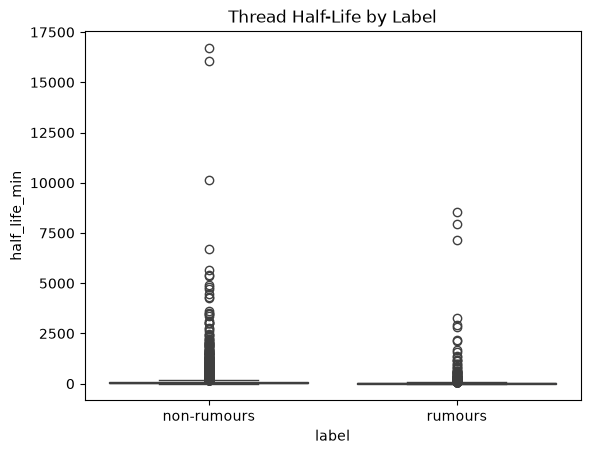

In [25]:
sns.boxplot(
    data=half_life_df,
    x="label",
    y="half_life_min"
)

plt.title("Thread Half-Life by Label")
plt.show()

The half-life distribution was highly right-skewed due to a small number of long-lived discussions. Therefore, median values were used for interpretation.

In [26]:
half_life_df.groupby("label")["half_life_min"].median()

label
non-rumours    25.733333
rumours        13.016667
Name: half_life_min, dtype: float64

In [27]:
half_life_df.groupby("label")["half_life_min"].quantile([0.25, 0.75])

label            
non-rumours  0.25    10.150000
             0.75    77.133333
rumours      0.25     6.016667
             0.75    30.770833
Name: half_life_min, dtype: float64

### Reply Growth Curves

In [28]:
checkpoints = [
    5,
    15,
    30,
    60,
    360,
    1440
]

growth_results = []

for cp in checkpoints:

    all_threads = df["thread_id"].unique()
    counts = (
        df[
            (df["is_source_tweet"] == 0)
            &
            (df["time_since_source_min"] <= cp)
        ]
        .groupby("thread_id")
        .size()
        .reindex(all_threads, fill_value=0)
        .rename("reply_count")
        .reset_index()
    )

    counts["label"] = counts["thread_id"].map(
        df.groupby("thread_id")["label_name"].first()
    )

    for label, group in counts.groupby("label"):

        growth_results.append({
            "checkpoint_min": cp,
            "label": label,
            "mean_replies": group["reply_count"].mean(),
            "median_replies": group["reply_count"].median()
        })

growth_df = pd.DataFrame(growth_results)

growth_df.head()

,checkpoint_min,label,mean_replies,median_replies
0,5,non-rumours,2.272063,1.0
1,5,rumours,2.911765,2.0
2,15,non-rumours,4.995822,3.0
3,15,rumours,5.834686,4.0
4,30,non-rumours,7.077546,5.0


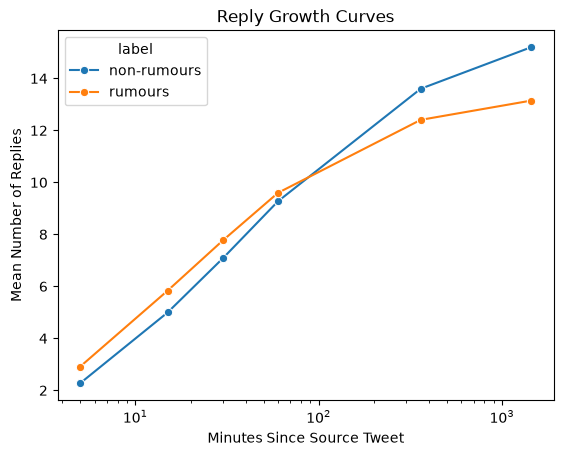

In [29]:
sns.lineplot(
    data=growth_df,
    x="checkpoint_min",
    y="mean_replies",
    hue="label",
    marker="o"
)

plt.title("Reply Growth Curves")
plt.xlabel("Minutes Since Source Tweet")
plt.ylabel("Mean Number of Replies")

plt.xscale("log")

plt.show()

Rumours spread faster early.

### **Structural Characteristics**

In [30]:
df.columns[df.columns.str.contains("id", case=False)]

Index(['in_reply_to_status_id', 'id', 'id_str', 'in_reply_to_user_id',
       'in_reply_to_user_id_str', 'in_reply_to_status_id_str', 'thread_id',
       'user_id', 'user_profile_sidebar_fill_color',
       'user_profile_sidebar_border_color', 'user_id_str', 'place_id'],
      dtype='str')

In [31]:
# Using existing string IDs
df["id_str"] = df["id_str"].astype(str)

# Cleaning parent IDs
df["parent_str"] = df["in_reply_to_status_id_str"]
df.loc[df["parent_str"].isna(), "parent_str"] = pd.NA

### 1. Maximum reply depth per thread (depth)
### 2. Maximum number of nodes at the same depth level(width) 

In [32]:
import networkx as nx

structure_results = []

for thread_id, group in df.groupby("thread_id"):

    G = nx.DiGraph()

    for _, row in group.iterrows():
        tweet_id = row["id_str"]
        parent = row["parent_str"]

        G.add_node(tweet_id)

        if pd.notna(parent):
            G.add_edge(parent, tweet_id)

    source = group[group["is_source_tweet"] == 1]

    if source.empty:
        continue

    source_id = source["id_str"].iloc[0]

    if source_id not in G:
        continue

    depths = nx.single_source_shortest_path_length(G, source_id)

    depth_values = list(depths.values())

    max_depth = max(depth_values)

    max_width = pd.Series(depth_values).value_counts().max()

    structure_results.append({
        "thread_id": thread_id,
        "label": group["label_name"].iloc[0],
        "depth": max_depth,
        "width": max_width
    })

structure_df = pd.DataFrame(structure_results)

structure_df.groupby("label")[["depth", "width"]].describe()

depth                                                 width  \
              count      mean       std  min  25%  50%  75%   max   count   
label                                                                       
non-rumours  3830.0  3.343081  3.778857  0.0  1.0  2.0  4.0  33.0  3830.0   
rumours      1972.0  2.886917  3.380922  0.0  1.0  2.0  3.0  47.0  1972.0   

                                                             
                 mean       std  min  25%  50%   75%    max  
label                                                        
non-rumours  8.530026  6.028574  1.0  4.0  8.0  12.0  122.0  
rumours      8.080629  5.362278  1.0  4.0  7.0  12.0   38.0

### Flat vs Nested Cascades

In [33]:
replies = df[df["is_source_tweet"] == 0].copy()

replies["cascade_type"] = np.where(
    replies["parent_str"] == replies["thread_id"].astype(str),
    "flat_source_reply",
    "nested_reply"
)

flat_nested = pd.crosstab(
    replies["label_name"],
    replies["cascade_type"],
    normalize="index"
) * 100

flat_nested.round(2)

cascade_type,flat_source_reply,nested_reply
label_name,,
non-rumours,50.93,49.07
rumours,58.47,41.53


### Branching Factor

In [34]:
branch_results = []

for thread_id, group in df.groupby("thread_id"):

    G = nx.DiGraph()

    for _, row in group.iterrows():
        tweet_id = row["id_str"]
        parent = row["parent_str"]

        G.add_node(tweet_id)

        if pd.notna(parent):
            G.add_edge(parent, tweet_id)

    internal_nodes = [
        n for n in G.nodes()
        if G.out_degree(n) > 0
    ]

    if len(internal_nodes) == 0:
        branching_factor = 0
    else:
        branching_factor = np.mean([
            G.out_degree(n)
            for n in internal_nodes
        ])

    branch_results.append({
        "thread_id": thread_id,
        "label": group["label_name"].iloc[0],
        "branching_factor": branching_factor
    })

branch_df = pd.DataFrame(branch_results)

branch_df.groupby("label")["branching_factor"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non-rumours,3830.0,3.859993,3.362438,0.0,1.833333,3.0,5.0,22.0
rumours,1972.0,3.888441,3.222736,0.0,2.000000,3.0,5.0,20.0


In [35]:
#Final Structural Summary

structural_summary = (
    structure_df
    .merge(branch_df, on=["thread_id", "label"], how="left")
)

structural_summary.groupby("label")[
    ["depth", "width", "branching_factor"]
].median()

,depth,width,branching_factor
label,,,
non-rumours,2.0,8.0,3.0
rumours,2.0,7.0,3.0


### **Semantic Characteristics**

In [36]:
import re
from collections import Counter

### Text Length

In [37]:
df["char_len"] = df["text"].astype(str).str.len()
df["word_len"] = df["text"].astype(str).str.split().str.len()

text_length_summary = (
    df.groupby("label_name")[["char_len", "word_len"]]
      .describe()
)

text_length_summary

char_len                                                         \
               count        mean        std  min   25%    50%    75%    max   
label_name                                                                    
non-rumours  65715.0  100.350468  35.727627  8.0  71.0  109.0  134.0  152.0   
rumours      28680.0   97.608298  36.498292  9.0  67.0  105.0  132.0  187.0   

            word_len                                                    
               count       mean       std  min   25%   50%   75%   max  
label_name                                                              
non-rumours  65715.0  14.853565  6.072426  1.0  10.0  15.0  20.0  34.0  
rumours      28680.0  14.579742  6.074808  1.0  10.0  15.0  19.0  32.0

### Entities

In [38]:
entity_cols = [
    "n_hashtags",
    "n_urls",
    "n_mentions",
    "n_media",
    "n_symbols"
]

entity_summary = (
    df.groupby("label_name")[entity_cols]
      .mean()
      .round(2)
)

entity_summary

,n_hashtags,n_urls,n_mentions,n_media,n_symbols
label_name,,,,,
non-rumours,0.29,0.09,1.73,0.09,0.0
rumours,0.29,0.13,1.62,0.08,0.0


### Top hashtags by label

In [39]:
def extract_hashtags(text):
    return re.findall(r"#\w+", str(text).lower())

hashtag_results = []

for label, group in df.groupby("label_name"):
    hashtags = []
    
    for text in group["text"]:
        hashtags.extend(extract_hashtags(text))
    
    top_tags = Counter(hashtags).most_common(10)
    
    for tag, count in top_tags:
        hashtag_results.append({
            "label": label,
            "hashtag": tag,
            "count": count
        })

top_hashtags_df = pd.DataFrame(hashtag_results)

top_hashtags_df

,label,hashtag,count
0,non-rumours,#ferguson,3269
1,non-rumours,#charliehebdo,2678
2,non-rumours,#sydneysiege,1303
3,non-rumours,#jesuischarlie,1082
4,non-rumours,#mikebrown,635
5,non-rumours,#illridewithyou,369
6,non-rumours,#germanwings,251
7,non-rumours,#ottawa,219
8,non-rumours,#ottawashooting,195
9,non-rumours,#paris,189


### Vocabulary Diversity per Thread(Type-Token ratio)

In [40]:
def tokenize(text):
    return re.findall(r"\b[a-zA-Z]{2,}\b", str(text).lower())

vocab_results = []

for thread_id, group in df.groupby("thread_id"):
    tokens = []
    
    for text in group["text"]:
        tokens.extend(tokenize(text))
    
    total_tokens = len(tokens)
    unique_tokens = len(set(tokens))
    
    ttr = unique_tokens / total_tokens if total_tokens > 0 else np.nan
    
    vocab_results.append({
        "thread_id": thread_id,
        "label": group["label_name"].iloc[0],
        "total_tokens": total_tokens,
        "unique_tokens": unique_tokens,
        "type_token_ratio": ttr
    })

vocab_df = pd.DataFrame(vocab_results)

vocab_df.groupby("label")[
    ["total_tokens", "unique_tokens", "type_token_ratio"]
].describe()

total_tokens                                                   \
                   count        mean         std  min   25%    50%    75%   
label                                                                       
non-rumours       3830.0  241.774674  314.709699  4.0  78.0  169.0  284.0   
rumours           1972.0  201.626775  235.749501  8.0  72.0  152.0  254.0   

                    unique_tokens              ...                  \
                max         count        mean  ...     75%     max   
label                                          ...                   
non-rumours  4849.0        3830.0  124.859269  ...  162.00  1272.0   
rumours      3171.0        1972.0  105.414300  ...  140.25   901.0   

            type_token_ratio                                          \
                       count      mean       std       min       25%   
label                                                                  
non-rumours           3830.0  0.621322  0.160747  0.128940  0.515209   
rumours               1972.0  0.614612  0.170147  0.097744  0.506346   

                                      
                  50%       75%  max  
label                                 
non-rumours  0.600000  0.709282  1.0  
rumours      0.594294  0.711721  1.0  

[2 rows x 24 columns]

In [41]:
semantic_summary = (
    vocab_df.groupby("label")
    [["total_tokens", "unique_tokens", "type_token_ratio"]]
    .median()
)

semantic_summary

,total_tokens,unique_tokens,type_token_ratio
label,,,
non-rumours,169.0,100.0,0.600000
rumours,152.0,84.5,0.594294


### **User Characteristics**

### Followers

In [42]:
followers_summary = (
    df.groupby("label_name")["user_followers_count"]
      .describe()
)

followers_summary

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
non-rumours,65715.0,61025.995846,7.264968e+05,0.0,112.0,461.0,1572.5,25303034.0
rumours,28680.0,136064.387727,1.184465e+06,0.0,104.0,423.0,1540.0,25303087.0


In [43]:
df.groupby("label_name")["user_followers_count"].median()

label_name
non-rumours    461.0
rumours        423.0
Name: user_followers_count, dtype: float64

### Friends

In [44]:
friends_summary = (
    df.groupby("label_name")["user_friends_count"]
      .describe()
)

friends_summary

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
non-rumours,65715.0,1423.475660,8584.526135,0.0,186.0,484.0,1183.0,423700.0
rumours,28680.0,1364.610181,6461.630989,0.0,188.0,472.0,1178.0,453460.0


In [45]:
df.groupby("label_name")["user_friends_count"].median()

label_name
non-rumours    484.0
rumours        472.0
Name: user_friends_count, dtype: float64

### Verified Users

In [46]:
verified_summary = (
    pd.crosstab(
        df["label_name"],
        df["user_verified"],
        normalize="index"
    ) * 100
)

verified_summary.round(2)

user_verified,False,True
label_name,,
non-rumours,95.77,4.23
rumours,94.09,5.91


In [47]:
df.groupby("label_name")["user_verified"].mean() * 100

label_name
non-rumours    4.231911
rumours        5.906555
Name: user_verified, dtype: float64

### Account Age

In [48]:
df["user_created_at"] = pd.to_datetime(
    df["user_created_at"],
    utc=True,
    errors="coerce"
)

#Calculating account age with tweet time
df["account_age_days"] = (
    df["created_at"] - df["user_created_at"]
).dt.days

account_age_summary = (
    df.groupby("label_name")["account_age_days"]
      .describe()
)

account_age_summary

/var/folders/k3/4xltyhr53vdgsxsvpd_vkhkw0000gn/T/ipykernel_67854/1535920148.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["user_created_at"] = pd.to_datetime(


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
non-rumours,65715.0,1228.189500,728.464291,0.0,594.0,1244.0,1905.0,3094.0
rumours,28680.0,1265.917922,728.770835,0.0,659.0,1282.0,1933.0,3093.0


In [49]:
df.groupby("label_name")["account_age_days"].median()

label_name
non-rumours    1244.0
rumours        1282.0
Name: account_age_days, dtype: float64

In [50]:
user_summary = pd.DataFrame({
    "median_followers":
        df.groupby("label_name")["user_followers_count"].median(),

    "median_friends":
        df.groupby("label_name")["user_friends_count"].median(),

    "verified_pct":
        round(
            df.groupby("label_name")["user_verified"].mean() * 100,
            2
        ),

    "median_account_age_days":
        df.groupby("label_name")["account_age_days"].median()
})

user_summary

,median_followers,median_friends,verified_pct,median_account_age_days
label_name,,,,
non-rumours,461.0,484.0,4.23,1244.0
rumours,423.0,472.0,5.91,1282.0
